In [15]:
import pandas as pd
from scipy.stats import kendalltau
import matplotlib.pyplot as plt

In [16]:
from pathlib import Path

blog_visuals = Path("../visuals")
blog_visuals.mkdir(parents=True, exist_ok=True)

def export_figure(fig, filename, dpi=220, width_px=None, aspect=None, tight=False, pad_inches=0.08):
    if width_px is not None and aspect is not None:
        fig.set_size_inches(width_px / dpi, (width_px * aspect) / dpi)
    out = blog_visuals / filename
    bbox = "tight" if tight else None
    fig.savefig(out, dpi=dpi, bbox_inches=bbox, pad_inches=pad_inches)
    print(f"Saved figure: {out.resolve()}")
    return out

def md_image(path, display_width_px=680):
    rel = path.relative_to(blog_visuals.parent)
    print(f"<img class=\"post-figure\" src=\"{rel.as_posix()}\" width=\"{display_width_px}\" />")

In [17]:
df = pd.read_csv("data/rankings.csv")

results = []
for year in sorted(df["year"].unique()):
    pre = df[(df["year"] == year) & (df["poll"] == "pre")][["team", "rank"]].set_index("team")["rank"]
    post = df[(df["year"] == year) & (df["poll"] == "post")][["team", "rank"]].set_index("team")["rank"]

    year_teams = sorted(set(pre.index) | set(post.index))

    pre_fill = pre.max() + 1
    post_fill = post.max() + 1

    pre_full = pre.reindex(year_teams).fillna(pre_fill)
    post_full = post.reindex(year_teams).fillna(post_fill)

    full_tau_b, full_p_value = kendalltau(pre_full, post_full, variant="b",
                                          method="asymptotic", alternative="greater")

    top_15_teams = [team for team in year_teams if (pre_full.loc[team] <= 15) or (post_full.loc[team] <= 15)]
    pre_top_15 = pre_full.reindex(top_15_teams)
    post_top_15 = post_full.reindex(top_15_teams)
    top_15_tau_b, top_15_p_value = kendalltau(pre_top_15, post_top_15, variant="b",
                                              method="asymptotic", alternative="greater")

    results.append({
        "year": int(year),
        "n_teams_full": len(year_teams),
        "full_tau_b": full_tau_b,
        "full_p_value": full_p_value,
        "n_teams_top_15_union": len(top_15_teams),
        "top_15_tau_b": top_15_tau_b,
        "top_15_p_value": top_15_p_value,
    })

tau_b_summary = pd.DataFrame(results).sort_values("year").reset_index(drop=True)
tau_b_summary

,year,n_teams_full,full_tau_b,full_p_value,n_teams_top_15_union,top_15_tau_b,top_15_p_value
0,2014,59,0.313677,0.000435,21,0.081146,0.303772
1,2015,55,0.174389,0.037274,22,0.013158,0.466194
2,2016,54,0.129748,0.091597,21,0.237306,0.068614
3,2017,54,0.278811,0.002493,20,0.131927,0.208529
4,2018,53,0.140381,0.076416,22,0.131294,0.198262
5,2019,60,0.293973,0.000880,20,0.336842,0.018927
6,2020,59,0.139643,0.070936,22,0.179825,0.123130
7,2021,57,0.016032,0.434733,23,0.061227,0.344700
8,2022,60,-0.012276,0.552049,22,-0.022422,0.556624
9,2023,60,0.283282,0.001134,19,0.194118,0.123854


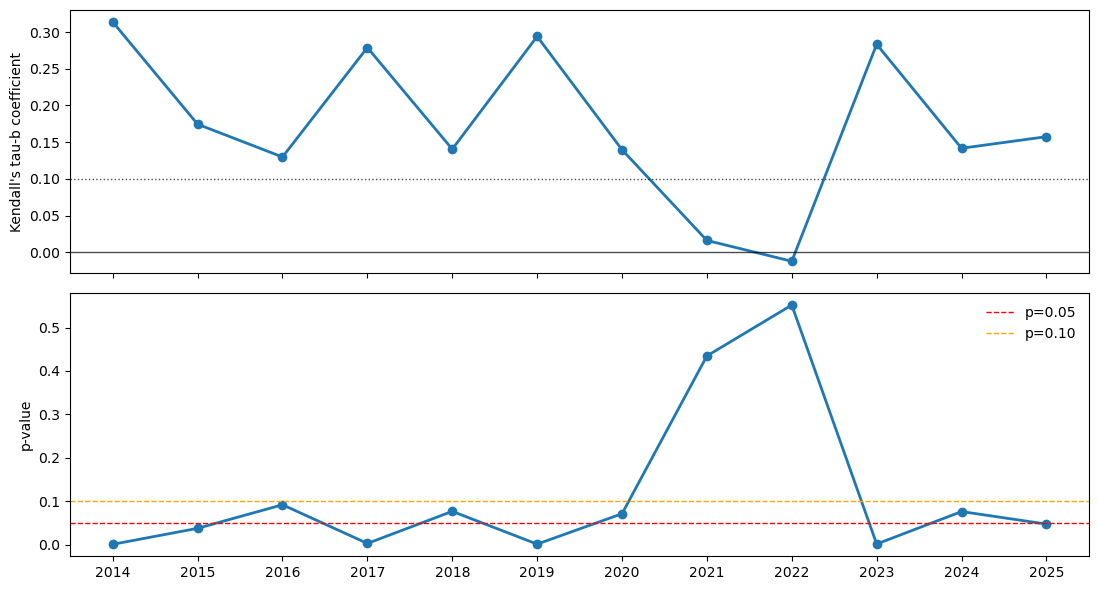

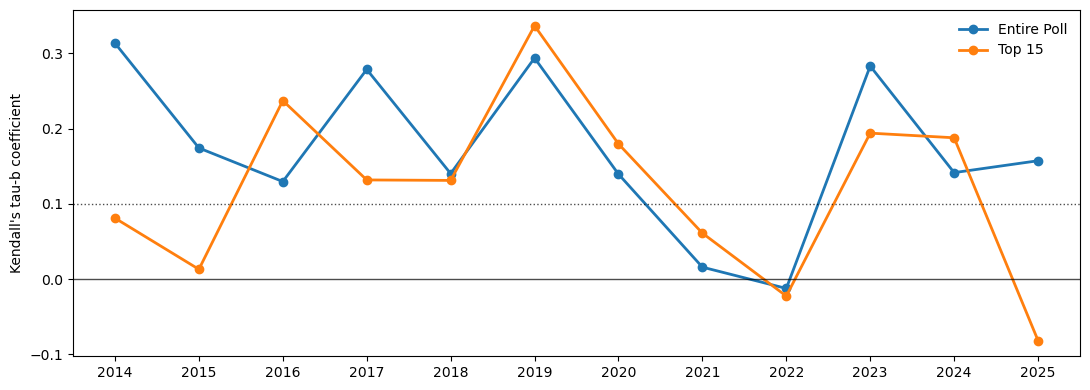

In [18]:
plot_df = tau_b_summary.copy()
years = plot_df["year"]
xlim = (2013.5, 2025.5)
xticks = list(range(2014, 2026))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(years, plot_df["full_tau_b"], marker="o", linewidth=2)
axes[0].axhline(0, color="black", linewidth=1, linestyle="-", alpha=0.7)
axes[0].axhline(0.1, color="black", linewidth=1, linestyle=":", alpha=0.7)
axes[0].set_ylabel("Kendall's tau-b coefficient")
axes[0].set_xlim(xlim)

axes[1].plot(years, plot_df["full_p_value"], marker="o", linewidth=2)
axes[1].axhline(0.05, color="red", linewidth=1, linestyle="--", label="p=0.05")
axes[1].axhline(0.1, color="orange", linewidth=1, linestyle="--", label="p=0.10")
axes[1].set_ylabel("p-value")
axes[1].set_xticks(xticks)
axes[1].set_xlim(xlim)
axes[1].legend(frameon=False)

plt.tight_layout()
full_poll_fig = fig
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(years, plot_df["full_tau_b"], marker="o", linewidth=2, label="Entire Poll")
ax.plot(years, plot_df["top_15_tau_b"], marker="o", linewidth=2, color="#ff7f0e", label="Top 15")
ax.axhline(0, color="black", linewidth=1, linestyle="-", alpha=0.7)
ax.axhline(0.1, color="black", linewidth=1, linestyle=":", alpha=0.7)
ax.set_ylabel("Kendall's tau-b coefficient")
ax.set_xticks(xticks)
ax.set_xlim(xlim)
ax.legend(frameon=False)
plt.tight_layout()
top15_vs_full_fig = fig
plt.show()

In [ ]:
all_years = sorted(df["year"].unique())
all_teams = sorted(df["team"].unique())

pair_rows = []
for year in all_years:
    pre = df[(df["year"] == year) & (df["poll"] == "pre")][["team", "rank"]].set_index("team")["rank"]
    post = df[(df["year"] == year) & (df["poll"] == "post")][["team", "rank"]].set_index("team")["rank"]

    year_teams = sorted(set(pre.index) | set(post.index))

    team_discordant = {team: 0 for team in all_teams}
    team_concordant = {team: 0 for team in all_teams}

    if year_teams:
        pre_fill = pre.max() + 1
        post_fill = post.max() + 1

        pre_full = pre.reindex(year_teams).fillna(pre_fill)
        post_full = post.reindex(year_teams).fillna(post_fill)

        for i in range(len(year_teams)):
            team_i = year_teams[i]
            for j in range(i + 1, len(year_teams)):
                team_j = year_teams[j]

                pre_diff = pre_full.loc[team_i] - pre_full.loc[team_j]
                post_diff = post_full.loc[team_i] - post_full.loc[team_j]

                if (pre_diff == 0) or (post_diff == 0):
                    continue

                sign_product = pre_diff * post_diff
                if sign_product < 0:
                    team_discordant[team_i] += 1
                    team_discordant[team_j] += 1
                elif sign_product > 0:
                    team_concordant[team_i] += 1
                    team_concordant[team_j] += 1

    for team in all_teams:
        pair_rows.append({
            "year": int(year),
            "team": team,
            "discordant_pairs": team_discordant[team],
            "concordant_pairs": team_concordant[team],
        })

team_pair_counts = (
    pd.DataFrame(pair_rows)
    .sort_values(["year", "discordant_pairs"], ascending=[True, False])
    .reset_index(drop=True)
)

avg_pair_counts = (
    team_pair_counts.groupby("team", as_index=False)
    .agg(avg_discordant_pairs=("discordant_pairs", "mean"),
         avg_concordant_pairs=("concordant_pairs", "mean"))
)

top_avg_discordant = (
    avg_pair_counts.sort_values("avg_discordant_pairs", ascending=False)
    .reset_index(drop=True)
)
top_avg_concordant = (
    avg_pair_counts.sort_values("avg_concordant_pairs", ascending=False)
    .reset_index(drop=True)
)

top_avg_discordant.head(15)

,team,avg_discordant_pairs,avg_concordant_pairs
0,TCU,25.333333,21.916667
1,Boise State,23.083333,28.083333
2,Iowa,23.000000,28.000000
3,USC,19.750000,31.833333
4,Texas A&M,19.416667,29.666667
5,Utah,19.083333,31.500000
6,Auburn,18.916667,26.166667
7,Oklahoma State,18.416667,25.500000
8,LSU,18.083333,33.000000
9,Wisconsin,18.083333,28.583333


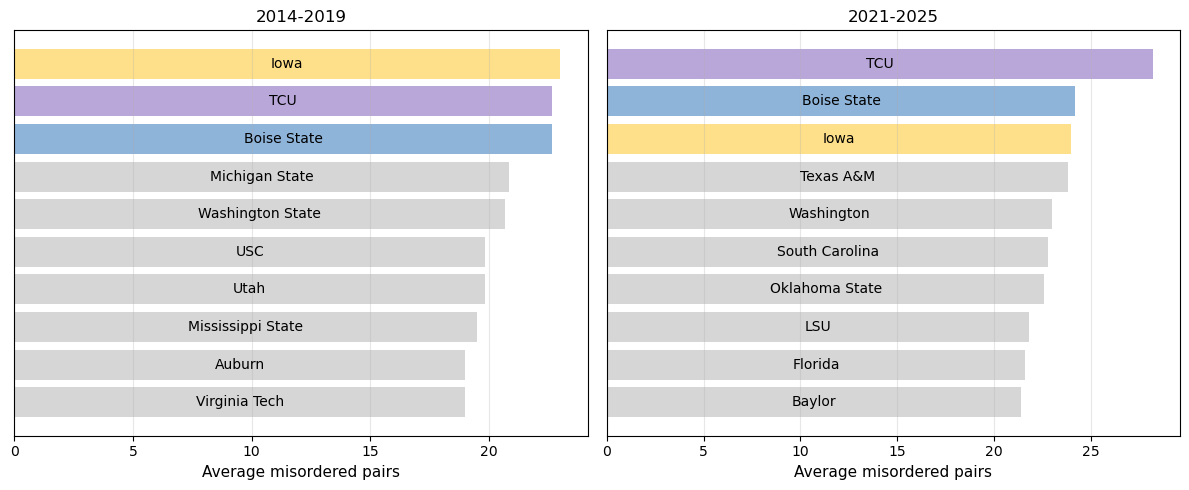

In [20]:
early = team_pair_counts[(team_pair_counts["year"] >= 2014) & (team_pair_counts["year"] <= 2019)]
recent = team_pair_counts[(team_pair_counts["year"] >= 2021) & (team_pair_counts["year"] <= 2025)]

early_avg = (
    early.groupby("team", as_index=False)["discordant_pairs"]
    .mean()
    .sort_values("discordant_pairs", ascending=False)
    .head(10)
    .sort_values("discordant_pairs", ascending=True)
)

recent_avg = (
    recent.groupby("team", as_index=False)["discordant_pairs"]
    .mean()
    .sort_values("discordant_pairs", ascending=False)
    .head(10)
    .sort_values("discordant_pairs", ascending=True)
)

def color_map(team):
    if team == "TCU": return "#b9a7d9"
    elif team == "Boise State": return "#8fb4d9"
    elif team == "Iowa": return "#ffe08a"
    else: return "#d6d6d6"

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
team_label_fs = 10
axis_label_fs = 11
title_fs = 12
tick_fs = 10

for ax, df, title in zip(axes, [early_avg, recent_avg], ["2014-2019", "2021-2025"]):
    y_pos = range(len(df))
    colors = [color_map(team) for team in df["team"]]
    bars = ax.barh(y_pos, df["discordant_pairs"], color=colors)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([""] * len(df))
    ax.tick_params(axis="y", length=0)
    ax.bar_label(bars, labels=df["team"], label_type="center", fontsize=team_label_fs, color="black")
    ax.set_xlabel("Average misordered pairs", fontsize=axis_label_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="x", labelsize=tick_fs)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
erratic_teams_fig = fig
plt.show()

In [21]:
full_path = export_figure(full_poll_fig, "kendall-full-with-pvalue.png")
top15_path = export_figure(top15_vs_full_fig, "kendall-full-vs-top15.png")
erratic_path = export_figure(erratic_teams_fig, "erratic-teams.png")
md_image(full_path)
md_image(top15_path)
md_image(erratic_path)

Saved figure: /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.05 CFB Preseason/visuals/kendall-full-with-pvalue.png
Saved figure: /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.05 CFB Preseason/visuals/kendall-full-vs-top15.png
Saved figure: /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.05 CFB Preseason/visuals/erratic-teams.png
<img class="post-figure" src="visuals/kendall-full-with-pvalue.png" width="680" />
<img class="post-figure" src="visuals/kendall-full-vs-top15.png" width="680" />
<img class="post-figure" src="visuals/erratic-teams.png" width="680" />
